In [ ]:
BATCH_SIZE = 32

WIDTH = 9
HEIGHT = 9
NUM_AGENTS = 4
LEARNING_RATE = 0.0001
CONV_CHANNELS = [32, 64, 64]
KERNEL_SIZE = 3

MODEL_SAVE_PATH = f"reward_model_{WIDTH}x{HEIGHT}_{NUM_AGENTS}a.pt"

DEBUG = False

In [2]:
import sys
sys.path.append('../../../')
from tadd_helpers.env_functions import State
import pickle
import numpy as np
from models.cnn import CNNDecentralized
from matplotlib import pyplot as plt
from tqdm import tqdm
from pathlib import Path
import torch

import pandas as pd
import seaborn as sns


--- PyTorch is configured to use: cpu ---


In [3]:
MODEL_SAVE_PATH = Path(MODEL_SAVE_PATH)
if not MODEL_SAVE_PATH.exists():
    MODEL_SAVE_PATH.mkdir(parents=True)


In [4]:
def get_decentralized_reward_when_picked(picked: bool, picker_index, picker_pos, all_agents) -> dict[int, float]:
    """Return decentralized reward of all agents

    Args:
        picked (bool): Whether an agent has picked an apple
        picker_index: _description_
        picker_pos: _description_
        all_agents: dict[int, tuple]: Mapping from agent index to (x, y) position
    """
    res: dict[int, float] = {}
    
    if not picked:
        for agent_idx in all_agents.keys():
            res[agent_idx] = 0.0
        return res

    res[picker_index] = -1

    # Calculate distances from ALL agents to the picker
    all_agent_positions = np.array(list(all_agents.values()))
    distances = np.linalg.norm(all_agent_positions - np.array(picker_pos), axis=1)
    sum_of_distances = np.sum(distances)
    
    for agent_idx in all_agents.keys():
        if agent_idx == picker_index:
            continue
        agent_pos = all_agents[agent_idx]
        agent_distance = np.linalg.norm(np.array(agent_pos) - np.array(picker_pos))
        if sum_of_distances == 0:
            res[agent_idx] = 0.0
        else:
            res[agent_idx] = 2 * agent_distance / sum_of_distances
    return res

def get_picker_index_and_pos_from_state(state: State):
    """Extract the picker index and position from the state. 

    Args:
        state (State): The current environment state
    Returns:
        picked: bool: Whether an agent has picked an apple
        picker_index (int): The index of the picker agent
        picker_pos (tuple): The (x, y) position of the picker agent 
    """
    picked = False
    picker_index = -1
    picker_pos = (-1, -1)
    for agent_idx, agent_pos in state._agents.items():
        # check if the agent_pos is in the apples nd array
        if state._apples[agent_pos] >= 1:
            picked = True
            picker_index = agent_idx
            picker_pos = agent_pos
            break
    return picked, picker_index, picker_pos

def get_decentralized_reward_from_state(state: State) -> dict[int, float]:
    """Calculate the decentralized reward for the self-agent based on the state.

    Args:
        state (State): The current environment state
    Returns:
        dict[int, float]: The decentralized rewards for all agents
    """
    picked, picker_index, picker_pos = get_picker_index_and_pos_from_state(state)
    all_agents = state._agents
    rewards = get_decentralized_reward_when_picked(picked, picker_index, picker_pos, all_agents)
    return rewards

In [5]:
states: list[State] = []
states_file_path = f"centralized_model{WIDTH}x{HEIGHT}_agents{NUM_AGENTS}/trained_states_centralized.pkl"
with open(states_file_path, "rb") as f:
    states = pickle.load(f)

In [6]:
# tmp cell
if DEBUG:
    states = states[:100]

In [7]:
cnns: list[CNNDecentralized] = []
for i in range(NUM_AGENTS):
    model = CNNDecentralized(WIDTH, HEIGHT, LEARNING_RATE, 128, 2, CONV_CHANNELS, KERNEL_SIZE)
    cnns.append(model)

states_to_eval = states
losses = []
for i, state in tqdm(enumerate(states_to_eval), total=len(states_to_eval)):
    rewards = get_decentralized_reward_from_state(state)
    assert len(rewards.values()) == len(cnns), f"Mismatch between rewards and CNN models on state {i}"
    for idx in range(len(rewards)):
        reward = rewards[idx]
        cnns[idx].add_experience_from_raw(cnns[idx].state_to_raw_dict(state), reward, agent_pos=state.agent_position(idx))
        if len(cnns[idx].batch_states) >= BATCH_SIZE:
            loss = cnns[idx].train_batch(BATCH_SIZE)
            losses.append(loss)
        
    

100%|██████████| 100/100 [00:00<00:00, 430.32it/s]


Text(0.5, 1.0, 'Training Loss over Time')

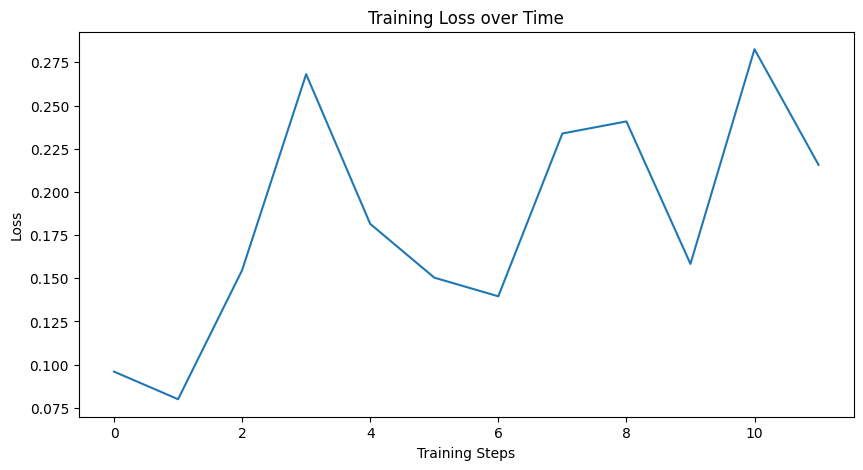

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss over Time')

In [11]:


def evaluate_reward_model(cnns: list[CNNDecentralized], states):
    """
    Evaluates the trained CNNs on the provided states and returns detailed statistics.
    """
    results = []
    
    print("Starting Evaluation...")
    
    # Set models to eval mode
    for cnn in cnns:
        cnn.eval()

    with torch.no_grad():
        for state_idx, state in tqdm(enumerate(states), total=len(states)):
            # 1. Get True Rewards
            true_rewards_dict = get_decentralized_reward_from_state(state)
            
            # 2. Get Predicted Rewards from each agent's CNN
            for agent_idx, true_reward in true_rewards_dict.items():
                cnn = cnns[agent_idx]
                
                # Prepare input
                # Note: We use the single-item inference method
                processed_state = cnn.raw_state_to_nn_input(
                    cnn.state_to_raw_dict(state), 
                    agent_pos=state.agent_position(agent_idx)
                )
                
                # Forward pass (add batch dim)
                pred_reward = cnn.get_model_reward_prediction_from_proccessed_state(processed_state).item()
                
                # 3. Categorize
                category = "Zero"
                if true_reward == -1:
                    category = "Picker"
                elif true_reward > 0:
                    category = "Non-Picker"
                
                results.append({
                    "agent_idx": agent_idx,
                    "category": category,
                    "true_reward": true_reward,
                    "pred_reward": pred_reward,
                    "abs_error": abs(true_reward - pred_reward),
                    "error": pred_reward - true_reward # Signed error to check bias
                })

    df = pd.DataFrame(results)
    return df

# --- RUN EVALUATION ---
df_results = evaluate_reward_model(cnns, states_to_eval)


Starting Evaluation...


100%|██████████| 100/100 [00:00<00:00, 291.14it/s]


In [12]:

# --- CALCULATE METRICS ---

# 1. Zero Reward (Focus on MAE - Hallucinations)
zero_stats = df_results[df_results['category'] == "Zero"]
mae_zero = zero_stats['abs_error'].mean()
print(f"\n=== ZERO REWARD STATS ===")
print(f"Count: {len(zero_stats)}")
print(f"MAE (Hallucination Level): {mae_zero:.5f}")
print(f"Max Error: {zero_stats['abs_error'].max():.5f}")

# 2. Picker Reward (Target is -1, Focus on MAE/Accuracy)
picker_stats = df_results[df_results['category'] == "Picker"]
mae_picker = picker_stats['abs_error'].mean()
print(f"\n=== PICKER REWARD (-1) STATS ===")
print(f"Count: {len(picker_stats)}")
print(f"MAE: {mae_picker:.5f}")
# Calculate MAPE just for consistency, though MAE is better here since target is constant
print(f"MAPE: {(picker_stats['abs_error'] / 1.0).mean() * 100:.2f}%")

# 3. Non-Picker Reward (Target > 0, Focus on MAPE - Relative Error)
non_picker_stats = df_results[df_results['category'] == "Non-Picker"]
mae_np = non_picker_stats['abs_error'].mean()
# Avoid division by zero (though category definition prevents it)
mape_np = (non_picker_stats['abs_error'] / non_picker_stats['true_reward']).mean() * 100

print(f"\n=== NON-PICKER REWARD (>0) STATS ===")
print(f"Count: {len(non_picker_stats)}")
print(f"Mean True Value: {non_picker_stats['true_reward'].mean():.5f}")
print(f"MAE: {mae_np:.5f}")
print(f"MAPE (Relative Error): {mape_np:.2f}%")



=== ZERO REWARD STATS ===
Count: 288
MAE (Hallucination Level): 0.05934
Max Error: 0.11213

=== PICKER REWARD (-1) STATS ===
Count: 28
MAE: 0.99569
MAPE: 99.57%

=== NON-PICKER REWARD (>0) STATS ===
Count: 84
Mean True Value: 0.66667
MAE: 0.66256
MAPE (Relative Error): 101.46%


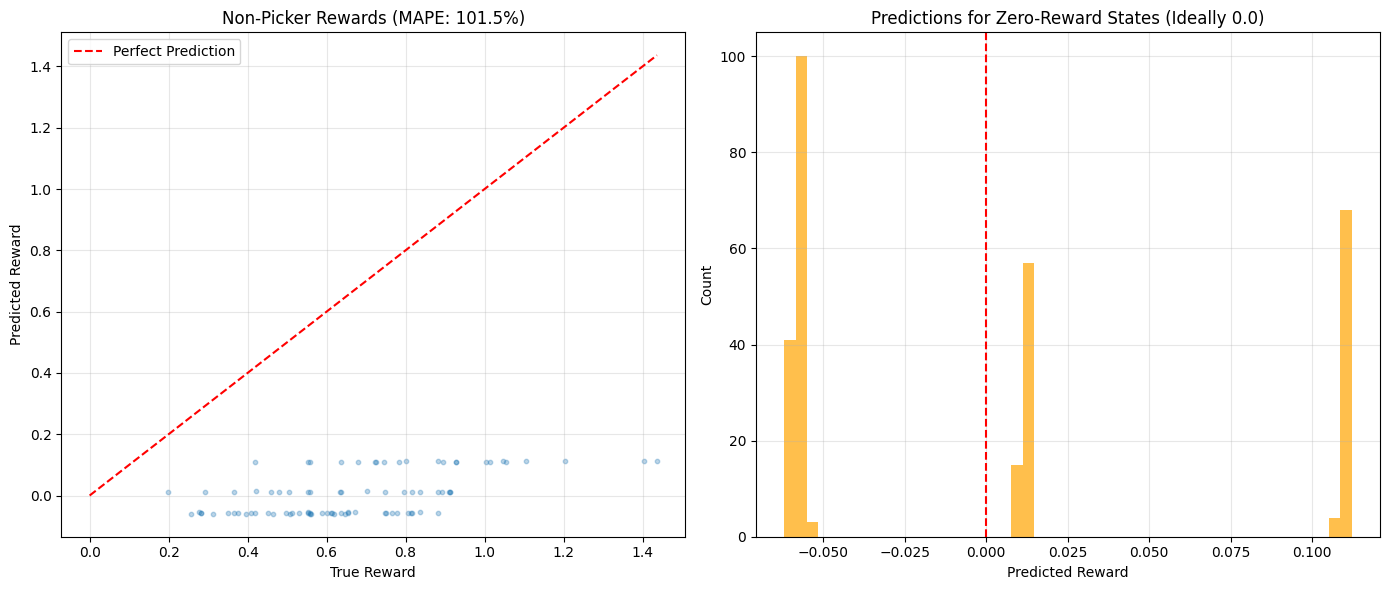

In [13]:

# --- VISUALIZATIONS ---

plt.figure(figsize=(14, 6))

# Plot 1: Scatter of True vs Predicted (Non-Picker Only)
plt.subplot(1, 2, 1)
plt.scatter(non_picker_stats['true_reward'], non_picker_stats['pred_reward'], alpha=0.3, s=10)
# Plot perfect prediction line
max_val = max(non_picker_stats['true_reward'].max(), non_picker_stats['pred_reward'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
plt.xlabel("True Reward")
plt.ylabel("Predicted Reward")
plt.title(f"Non-Picker Rewards (MAPE: {mape_np:.1f}%)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Distribution of Predicted Values for Zero-Reward States (Hallucinations)
plt.subplot(1, 2, 2)
plt.hist(zero_stats['pred_reward'], bins=50, color='orange', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--')
plt.xlabel("Predicted Reward")
plt.ylabel("Count")
plt.title(f"Predictions for Zero-Reward States (Ideally 0.0)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()